In [3]:
from rasterio.mask import mask
import rasterio
import geopandas as gpd

In [74]:
tif_path = "data/landscan-global-2024.tif"
with rasterio.open(tif_path) as src:
     #We'll use this for all other rasters 
    target_crs = src.crs
    target_transform = src.transform
    target_width = src.width
    target_height = src.height
    
    boundary_cropto = gpd.read_file('data/adm0_africa/adm0_africa.shp')
    # Ensure that both shape file and Population raster file has same CRS
    boundary_cropto = boundary_cropto.set_crs("EPSG:4326")
    boundary_cropto = boundary_cropto.to_crs(src.crs)

    out_image, out_transform = mask(src, boundary_cropto.geometry, crop=True)
    out_meta = src.meta.copy()

# Update metadata for the new clipped file
out_meta.update({
    "driver": "GTiff",
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform
})

#Save the result
with rasterio.open("data/landscan-africa-2024.tif", "w", **out_meta) as dest:
    dest.write(out_image)

In [75]:
!gdal_translate -of GTiff data/landscan-africa-2024.tif data/landscan-africa-2024-compressed.tif -co COMPRESS=DEFLATE -co TILED=YES -co PREDICTOR=2

Input file size is 9589, 8659
0...10...20...30...40...50...60...70...80...90...100 - done.


<Axes: >

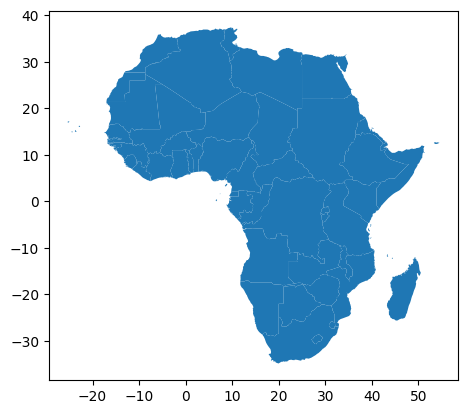

In [77]:
boundary = gpd.read_file('data/adm0_africa/adm0_africa.shp')
boundary = boundary.set_crs("EPSG:4326")
boundary = boundary.simplify(0.01)
boundary.plot()

<Axes: >

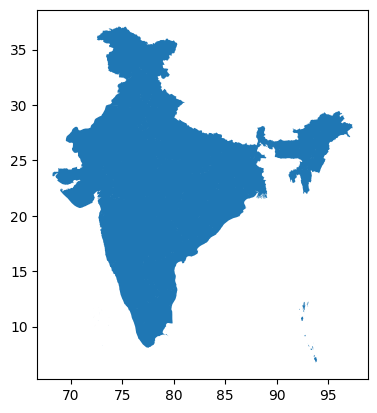

In [48]:
india['c'] = 1
india = india.dissolve('c')
india.plot()

In [52]:
india['NAME'] = 'India'
india['GMI_CNTRY'] = 'IND'
india['REGION'] = 'Asia'
india

,geometry,NAME,GMI_CNTRY,REGION
c,,,,
1,"MULTIPOLYGON (((73.01822 8.27141, 73.01735 8.2...",India,IND,Asia


In [54]:
boundary = boundary.drop(3)
boundary

,NAME,GMI_CNTRY,REGION,geometry
0,Afghanistan,AFG,Asia,"POLYGON ((65.6273 37.3332, 65.64693 37.45888, ..."
1,Bangladesh,BGD,Asia,"MULTIPOLYGON (((90.64886 21.9911, 90.64636 22...."
2,Bhutan,BTN,Asia,"POLYGON ((88.75055 27.14727, 88.80635 27.25305..."
4,Nepal,NPL,Asia,"POLYGON ((80.85858 30.17471, 80.90414 30.21693..."
5,Pakistan,PAK,Asia,"POLYGON ((74.56775 37.02647, 74.6908 37.06276,..."
6,Sri Lanka,LKA,Asia,"POLYGON ((79.79344 7.59953, 79.75554 7.86583, ..."


<Axes: >

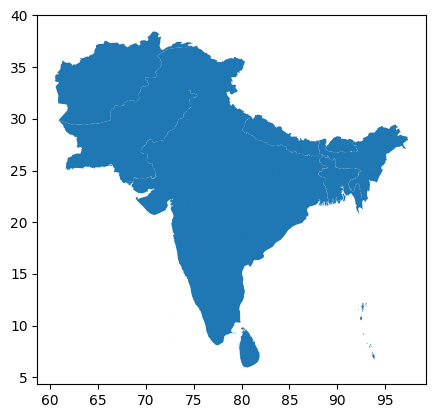

In [63]:
import pandas as pd
gpd.GeoDataFrame(pd.concat([boundary,india])).plot()

In [78]:
boundary.to_file('data/africa_boundary.geojson')